# Housing ML Model Proof-Of-Concept
## API Calls
to noise, pollution, crime, and housing price index datasets

In [1]:
import requests
import itertools
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

EUROSTAT_BASE = "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data"

def get_stat(dataset_code):
    url = f"{EUROSTAT_BASE}/{dataset_code}"
    params = {"format": "JSON", "lang": "en"}
    response = requests.get(url, params=params)
    response.raise_for_status()
    return response.json()

def eurostat_to_df(data):
    dims = {
        dim: list(info["category"]["label"].values())
        for dim, info in data["dimension"].items()
    }
    keys = list(itertools.product(*dims.values()))
    values = [data["value"].get(str(i)) for i in range(len(keys))]
    df = pd.DataFrame(keys, columns=dims.keys())
    df["value"] = values
    return df

noise = get_stat("ilc_mddw04")
pollution = get_stat("ilc_mddw05")
crime = get_stat("ilc_mddw06")
hpi = get_stat("prc_hpi_a")

df_noise = eurostat_to_df(noise)
df_pollution = eurostat_to_df(pollution)
df_crime = eurostat_to_df(crime)
df_hpi = eurostat_to_df(hpi)

df_noise.to_csv("noise.csv", index=False)
df_pollution.to_csv("pollution.csv", index=False)
df_crime.to_csv("crime.csv", index=False)
df_hpi.to_csv("hpi.csv", index=False)

## Initial Exploratory Data Analysis (EDA)

In [2]:
df_noise = pd.read_csv('noise.csv')
df_pollution = pd.read_csv('pollution.csv')
df_crime = pd.read_csv('crime.csv')
df_hpi = pd.read_csv('hpi.csv')

# noise
print("noise:\n",
    df_noise.head(), "\n",
    df_noise.shape, "\n",
    df_noise.columns.tolist(), "\n",
    df_noise.isnull())


noise:
      freq        unit deg_urb   rskpovth  \
0  Annual  Percentage  Cities  Below 60%   
1  Annual  Percentage  Cities  Below 60%   
2  Annual  Percentage  Cities  Below 60%   
3  Annual  Percentage  Cities  Below 60%   
4  Annual  Percentage  Cities  Below 60%   

                                                 geo  time  value  
0  European Union (EU6-1958, EU9-1973, EU10-1981,...  2003    NaN  
1  European Union (EU6-1958, EU9-1973, EU10-1981,...  2004    NaN  
2  European Union (EU6-1958, EU9-1973, EU10-1981,...  2005    NaN  
3  European Union (EU6-1958, EU9-1973, EU10-1981,...  2006    NaN  
4  European Union (EU6-1958, EU9-1973, EU10-1981,...  2007    NaN   
 (7182, 7) 
 ['freq', 'unit', 'deg_urb', 'rskpovth', 'geo', 'time', 'value'] 
        freq   unit  deg_urb  rskpovth    geo   time  value
0     False  False    False     False  False  False   True
1     False  False    False     False  False  False   True
2     False  False    False     False  False  False   True
3  

In [3]:
# pollution
print("pollution:\n",
    df_pollution.head(), "\n",
    df_pollution.shape, "\n",
    df_pollution.columns, "\n",
    df_pollution.isnull())

pollution:
      freq        unit deg_urb   rskpovth  \
0  Annual  Percentage  Cities  Below 60%   
1  Annual  Percentage  Cities  Below 60%   
2  Annual  Percentage  Cities  Below 60%   
3  Annual  Percentage  Cities  Below 60%   
4  Annual  Percentage  Cities  Below 60%   

                                                 geo  time  value  
0  European Union (EU6-1958, EU9-1973, EU10-1981,...  2003    NaN  
1  European Union (EU6-1958, EU9-1973, EU10-1981,...  2004    NaN  
2  European Union (EU6-1958, EU9-1973, EU10-1981,...  2005    NaN  
3  European Union (EU6-1958, EU9-1973, EU10-1981,...  2006    NaN  
4  European Union (EU6-1958, EU9-1973, EU10-1981,...  2007    NaN   
 (7182, 7) 
 Index(['freq', 'unit', 'deg_urb', 'rskpovth', 'geo', 'time', 'value'], dtype='object') 
        freq   unit  deg_urb  rskpovth    geo   time  value
0     False  False    False     False  False  False   True
1     False  False    False     False  False  False   True
2     False  False    False     Fal

In [4]:
# crime
print("crime:\n",
    df_crime.head(), "\n",
    df_crime.shape, "\n",
    df_crime.columns, "\n",
    df_crime.isnull())

crime:
      freq        unit deg_urb   rskpovth  \
0  Annual  Percentage  Cities  Below 60%   
1  Annual  Percentage  Cities  Below 60%   
2  Annual  Percentage  Cities  Below 60%   
3  Annual  Percentage  Cities  Below 60%   
4  Annual  Percentage  Cities  Below 60%   

                                                 geo  time  value  
0  European Union (EU6-1958, EU9-1973, EU10-1981,...  2003    NaN  
1  European Union (EU6-1958, EU9-1973, EU10-1981,...  2004    NaN  
2  European Union (EU6-1958, EU9-1973, EU10-1981,...  2005    NaN  
3  European Union (EU6-1958, EU9-1973, EU10-1981,...  2006    NaN  
4  European Union (EU6-1958, EU9-1973, EU10-1981,...  2007    NaN   
 (7182, 7) 
 Index(['freq', 'unit', 'deg_urb', 'rskpovth', 'geo', 'time', 'value'], dtype='object') 
        freq   unit  deg_urb  rskpovth    geo   time  value
0     False  False    False     False  False  False   True
1     False  False    False     False  False  False   True
2     False  False    False     False  

In [5]:
# hpi
print("hpi:\n",
    df_hpi.head(), "\n",
    df_hpi.shape, "\n",
    df_hpi.columns, "\n",
    df_hpi.isnull())

hpi:
      freq purchase                            unit  \
0  Annual    Total  Annual average index, 2010=100   
1  Annual    Total  Annual average index, 2010=100   
2  Annual    Total  Annual average index, 2010=100   
3  Annual    Total  Annual average index, 2010=100   
4  Annual    Total  Annual average index, 2010=100   

                                                 geo  time   value  
0  European Union (EU6-1958, EU9-1973, EU10-1981,...  2005   86.98  
1  European Union (EU6-1958, EU9-1973, EU10-1981,...  2006   94.66  
2  European Union (EU6-1958, EU9-1973, EU10-1981,...  2007  102.84  
3  European Union (EU6-1958, EU9-1973, EU10-1981,...  2008  103.39  
4  European Union (EU6-1958, EU9-1973, EU10-1981,...  2009   98.81   
 (7182, 6) 
 Index(['freq', 'purchase', 'unit', 'geo', 'time', 'value'], dtype='object') 
        freq  purchase   unit    geo   time  value
0     False     False  False  False  False  False
1     False     False  False  False  False  False
2     False  

In [6]:
from collections import Counter

# Counter(df_noise['geo'])
# Counter(df_pollution['geo'])
# Counter(df_crime['geo'])
Counter(df_hpi['geo'])

Counter({'European Union (EU6-1958, EU9-1973, EU10-1981, EU12-1986, EU15-1995, EU25-2004, EU27-2007, EU28-2013, EU27-2020)': 189,
         'European Union - 27 countries (from 2020)': 189,
         'European Union - 28 countries (2013-2020)': 189,
         'Euro area (EA11-1999, EA12-2001, EA13-2007, EA15-2008, EA16-2009, EA17-2011, EA18-2014, EA19-2015, EA20-2023, EA21-2026)': 189,
         'Euro area – 21 countries (from 2026)': 189,
         'Euro area – 20 countries (2023-2025)': 189,
         'Euro area - 19 countries  (2015-2022)': 189,
         'Belgium': 189,
         'Bulgaria': 189,
         'Czechia': 189,
         'Denmark': 189,
         'Germany': 189,
         'Estonia': 189,
         'Ireland': 189,
         'Spain': 189,
         'France': 189,
         'Croatia': 189,
         'Italy': 189,
         'Cyprus': 189,
         'Latvia': 189,
         'Lithuania': 189,
         'Luxembourg': 189,
         'Hungary': 189,
         'Malta': 189,
         'Netherlands': 189,


In [7]:
Counter(df_hpi['value'])

Counter({100.0: 226,
         4.4: 32,
         4.6: 24,
         5.0: 23,
         4.8: 22,
         4.9: 21,
         6.0: 21,
         0.3: 19,
         1.1: 19,
         5.3: 19,
         2.5: 19,
         5.9: 19,
         7.5: 18,
         3.3: 18,
         6.7: 17,
         4.0: 17,
         2.2: 17,
         5.1: 17,
         4.7: 16,
         -2.1: 16,
         4.3: 16,
         5.6: 16,
         7.3: 16,
         5.2: 16,
         1.4: 16,
         3.5: 16,
         3.8: 16,
         5.7: 16,
         5.4: 15,
         3.7: 15,
         8.3: 15,
         6.2: 15,
         4.5: 15,
         4.2: 15,
         6.8: 15,
         0.7: 14,
         2.4: 14,
         3.0: 14,
         6.6: 14,
         -1.5: 14,
         6.4: 14,
         0.5: 13,
         8.5: 13,
         0.8: 13,
         7.8: 13,
         8.8: 12,
         1.2: 12,
         8.0: 12,
         3.4: 12,
         1.3: 12,
         -1.7: 12,
         2.3: 12,
         8.7: 12,
         4.1: 12,
         7.9: 12,
    

In [8]:
import pandas as pd
import numpy as np

# =============================================================================
# load and clean
# =============================================================================

df_noise     = pd.read_csv('noise.csv')
df_pollution = pd.read_csv('pollution.csv')
df_crime     = pd.read_csv('crime.csv')
df_hpi       = pd.read_csv('hpi.csv')

for df in [df_noise, df_pollution, df_crime, df_hpi]:
    df.rename(columns={'time': 'year'}, inplace=True)
    df.drop(df[df['geo'].str[0:4] == 'Euro'].index, inplace=True)
    df.dropna(subset=['value'], inplace=True)
    df['year'] = df['year'].astype(int)
    df['value'] = df['value'].astype(float)


# =============================================================================
# helper
# =============================================================================

def summary_stats(df, name):
    print(f"\n{'='*50}")
    print(f"  {name.upper()}")
    print(f"{'='*50}")
    print(f"  rows:       {len(df)}")
    print(f"  countries:  {df['geo'].nunique()}")
    print(f"  years:      {df['year'].min()} – {df['year'].max()}")
    print(f"  nulls:      {df['value'].isna().sum()}")
    print()
    s = df['value']
    print(f"  mean:       {s.mean():.2f}")
    print(f"  median:     {s.median():.2f}")
    print(f"  std dev:    {s.std():.2f}")
    print(f"  min:        {s.min():.2f}")
    print(f"  25th pct:   {s.quantile(0.25):.2f}")
    print(f"  75th pct:   {s.quantile(0.75):.2f}")
    print(f"  max:        {s.max():.2f}")
    print(f"  skewness:   {s.skew():.2f}")
    print(f"  kurtosis:   {s.kurt():.2f}")

    latest = df.sort_values('year', ascending=False).groupby('geo')['value'].first()
    print(f"\n  -- latest year per country --")
    print(f"  mean:       {latest.mean():.2f}")
    print(f"  std dev:    {latest.std():.2f}")
    print(f"\n  5 lowest:")
    for geo, val in latest.nsmallest(5).items():
        print(f"    {geo:<28} {val:.2f}")
    print(f"\n  5 highest:")
    for geo, val in latest.nlargest(5).items():
        print(f"    {geo:<28} {val:.2f}")

    yearly = df.groupby('year')['value'].mean()
    change = yearly.iloc[-1] - yearly.iloc[0]
    pct    = (change / yearly.iloc[0]) * 100
    direction = "decreased" if change < 0 else "increased"
    print(f"\n  trend: {direction} by {abs(change):.2f} pts ({abs(pct):.1f}%) from {yearly.index[0]} to {yearly.index[-1]}")


# =============================================================================
# individual summaries
# =============================================================================

summary_stats(df_noise,     'noise rate')
summary_stats(df_pollution, 'pollution rate')
summary_stats(df_crime,     'crime rate')
summary_stats(df_hpi,       'house price index')


# =============================================================================
# combined correlation matrix
# =============================================================================

df_combined = pd.read_csv('merged_crime_poll_noise_hpi.csv')
df_combined = df_combined[df_combined['geo'].str[0:4] != 'Euro'].dropna()

rate_cols = ['noise_rate', 'pollution_rate', 'crime_rate', 'hpi_weight']

print(f"\n{'='*50}")
print(f"combined dataset")
print(f"{'='*50}")
print(f"  rows:       {len(df_combined)}")
print(f"  countries:  {df_combined['geo'].nunique()}")
print(f"  years:      {df_combined['year'].min()} – {df_combined['year'].max()}")
print(f"\ndescriptive stats")
print(df_combined[rate_cols].describe().round(2).to_string())
print(f"\ncorrelation matrix")
print(df_combined[rate_cols].corr().round(2).to_string())
print(f"\nvariance")
for col in rate_cols:
    print(f"{col:<25}{df_combined[col].var():.2f}")


  NOISE RATE
  rows:       4879
  countries:  34
  years:      2003 – 2023
  nulls:      0

  mean:       17.77
  median:     16.40
  std dev:    8.50
  min:        0.00
  25th pct:   11.60
  75th pct:   22.90
  max:        92.60
  skewness:   0.86
  kurtosis:   1.69

  -- latest year per country --
  mean:       15.86
  std dev:    10.34

  5 lowest:
    Albania                      1.90
    North Macedonia              3.00
    Greece                       3.70
    Croatia                      4.90
    Iceland                      5.10

  5 highest:
    Portugal                     42.30
    Luxembourg                   37.10
    Malta                        36.70
    Netherlands                  33.70
    Finland                      29.60

  trend: decreased by 4.02 pts (19.5%) from 2003 to 2023

  POLLUTION RATE
  rows:       4879
  countries:  34
  years:      2003 – 2023
  nulls:      0

  mean:       13.90
  median:     11.90
  std dev:    8.17
  min:        0.00
  25th pct:  

## Clean Datasets

In [9]:
def clean_df(df, value_col):
    """Standardise column names, drop null values, etc."""
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(r"[^a-z0-9]+", "_", regex=True)
    )
    df = df.rename(columns={"value": value_col})
    df = df.dropna(subset=[value_col])
    if "time" in df.columns:
        df = df.rename(columns={"time": "year"})
    df = df[df['geo'].str[0:4] != 'Euro']
    df["year"] = df["year"].astype(int)
    df[value_col] = df[value_col].astype(float)
    return df

df_noise_clean = clean_df(df_noise, "noise_rate")
df_pollution_clean = clean_df(df_pollution, "pollution_rate")
df_crime_clean = clean_df(df_crime, "crime_rate")
df_hpi_clean = clean_df(df_hpi, "hpi_weight")

In [10]:
# hpi dataset cleaning for weight column (had to do this seperately because of the 'total' purchase column)
purchase_col = [c for c in df_hpi.columns if "purch" in c]

if purchase_col:
    purchase_col = purchase_col[0]
    df_hpi_total = df_hpi[df_hpi[purchase_col].str.lower().str.contains("total")].copy()
else:
    df_hpi_total = df_hpi.copy()

df_hpi_clean = clean_df(df_hpi_total, "hpi_weight")
df_hpi_clean.head(10)

,freq,purchase,unit,geo,year,hpi_weight
147,Annual,Total,"Annual average index, 2010=100",Belgium,2005,79.53
148,Annual,Total,"Annual average index, 2010=100",Belgium,2006,87.33
149,Annual,Total,"Annual average index, 2010=100",Belgium,2007,94.11
150,Annual,Total,"Annual average index, 2010=100",Belgium,2008,98.20
151,Annual,Total,"Annual average index, 2010=100",Belgium,2009,97.80
152,Annual,Total,"Annual average index, 2010=100",Belgium,2010,100.00
153,Annual,Total,"Annual average index, 2010=100",Belgium,2011,103.58
154,Annual,Total,"Annual average index, 2010=100",Belgium,2012,106.02
155,Annual,Total,"Annual average index, 2010=100",Belgium,2013,107.59
156,Annual,Total,"Annual average index, 2010=100",Belgium,2014,107.23


In [11]:
df_noise_clean.to_csv("noise_clean.csv", index=False)
df_pollution_clean.to_csv("pollution_clean.csv", index=False)
df_crime_clean.to_csv("crime_clean.csv", index=False)
df_hpi_clean.to_csv("hpi_clean.csv", index=False)

## Initial Data Visualizations

In [12]:
import pandas as pd
import plotly.express as px

# load raw CSVs
df_noise = pd.read_csv('noise.csv')
df_pollution = pd.read_csv('pollution.csv')
df_crime = pd.read_csv('crime.csv')
df_hpi = pd.read_csv('hpi.csv')

# standardise column names
for df in [df_noise, df_pollution, df_crime, df_hpi]:
    df.rename(columns={'time': 'year'}, inplace=True)

# drop EU aggregates and nulls
for df in [df_noise, df_pollution, df_crime, df_hpi]:
    df.drop(df[df['geo'].str[0:4] == 'Euro'].index, inplace=True)
    df.dropna(subset=['value'], inplace=True)
    df['year'] = df['year'].astype(int)
    df['value'] = df['value'].astype(float)

# label each dataset
df_noise['dataset'] = 'Noise'
df_pollution['dataset'] = 'Pollution'
df_crime['dataset'] = 'Crime'


# plot 1: distribution of values for each dataset

df_all = pd.concat([df_noise, df_pollution, df_crime], ignore_index=True)

fig1 = px.histogram(
    df_all, x='value', color='dataset', barmode='overlay',
    nbins=30, opacity=0.7,
    title='Distribution of rates across all country-years',
    labels={'value': 'Rate (% of population reporting)', 'dataset': 'Dataset'},
    color_discrete_map={'Noise': '#378ADD', 'Pollution': '#1D9E75', 'Crime': '#D85A30'}
)
fig1.show()
fig1.write_html('distribution.html', full_html=False, include_plotlyjs='cdn')


# plot 2: EU average trend over time per dataset

eu_trend = df_all.groupby(['dataset', 'year'])['value'].mean().reset_index()

fig2 = px.line(
    eu_trend, x='year', y='value', color='dataset',
    markers=True,
    title='EU average rate over time',
    labels={'value': 'Average rate (%)', 'year': 'Year', 'dataset': 'Dataset'},
    color_discrete_map={'Noise': '#378ADD', 'Pollution': '#1D9E75', 'Crime': '#D85A30'}
)
fig2.show()
fig2.write_html('eu_trend.html', full_html=False, include_plotlyjs='cdn')

# plot 3: average rate by country for each dataset (latest year)

for df, label, color in [
    (df_noise,     'Noise',      '#378ADD'),
    (df_pollution, 'Pollution',  '#1D9E75'),
    (df_crime,     'Crime',      '#D85A30'),
]:
    latest = (
        df.sort_values('year', ascending=False)
        .groupby('geo', as_index=False)['value']
        .first()
        .sort_values('value')
    )
    fig = px.bar(
        latest, x='value', y='geo', orientation='h',
        title=f'{label} rate by country (latest year)',
        labels={'value': f'{label} rate (%)', 'geo': ''},
        color_discrete_sequence=[color]
    )
    fig.show()
    fig.write_html(f'{label.lower()}_rate.html', full_html=False, include_plotlyjs='cdn')

# plot 4: rate distribution by degree of urbanisation (boxplot)

for df, label, color in [
    (df_noise,     'Noise',      '#378ADD'),
    (df_pollution, 'Pollution',  '#1D9E75'),
    (df_crime,     'Crime',      '#D85A30'),
]:
    urb_col = [c for c in df.columns if 'urb' in c.lower() or 'degurba' in c.lower()]
    if urb_col:
        fig = px.box(
            df, x=urb_col[0], y='value',
            title=f'{label} rate by degree of urbanisation',
            labels={'value': f'{label} rate (%)', urb_col[0]: 'Urbanisation'},
            color=urb_col[0]
        )
        fig.show()
        fig.write_html(f'{label.lower()}_urbanisation.html', full_html=False, include_plotlyjs='cdn')

# plot 5: HPI trend over time by country

# filter to total purchase type
hpi_total = df_hpi[df_hpi['purchase'].str.lower().str.contains('total', na=False)].copy() \
            if 'purchase' in df_hpi.columns else df_hpi.copy()

hpi_trend = hpi_total.groupby(['geo', 'year'])['value'].mean().reset_index()

fig5 = px.line(
    hpi_trend, x='year', y='value', color='geo',
    title='House price index over time by country',
    labels={'value': 'HPI (2010=100)', 'year': 'Year', 'geo': 'Country'}
)
fig5.update_traces(opacity=0.6)
fig5.show()
fig5.write_html('hpi_trend.html', full_html=False, include_plotlyjs='cdn')

### Aggregate all datasets to country and year to calculate a rate

In [13]:
def aggregate_to_country_year(df, value_col):
    """Mean-aggregate all extra dimensions down to geo x year."""
    return df.groupby(["geo", "year"], as_index=False)[value_col].mean()

agg_noise = aggregate_to_country_year(df_noise_clean, "noise_rate")
agg_pollution = aggregate_to_country_year(df_pollution_clean, "pollution_rate")
agg_crime = aggregate_to_country_year(df_crime_clean, "crime_rate")
agg_hpi = aggregate_to_country_year(df_hpi_clean, "hpi_weight")

### Merge into one feature table

In [14]:
merged = (
    agg_noise
    .merge(agg_pollution, on=["geo", "year"], how="inner")
    .merge(agg_crime, on=["geo", "year"], how="inner")
    .merge(agg_hpi, on=["geo", "year"], how="inner")
)

merged = merged.dropna()

print(f"Merged dataset: {merged.shape[0]} rows, {merged['geo'].nunique()} countries")
merged.head()
merged.to_csv("merged_crime_poll_noise_hpi.csv", index=False)

Merged dataset: 451 rows, 30 countries


### Feature engineering

In [15]:
# all features are scaled to with 0 as average with standard scaler
# `noise_rate`, `pollution_rate`, `crime_rate`: higher = worse
# `hpi_weight`: higher = more expensive

# `safety_score`: mean of scaled bad-metrics (lower = better)
# `safety_index`: inverted for display (higher = better)
# `affordability_index`: inverted scaled HPI alone (higher = more affordable)
# `combined_score`: weighted average of safety + affordability

feature_cols = ["noise_rate", "pollution_rate", "crime_rate", "hpi_weight"]

scaler = StandardScaler()
scaled = scaler.fit_transform(merged[feature_cols])

merged = merged[[c for c in merged.columns if not c.endswith('_scaled')]]
scaled_df = pd.DataFrame(
    scaled,
    columns=[f"{c}_scaled" for c in feature_cols],
    index=merged.index
)
merged = pd.concat([merged, scaled_df], axis=1)

# safety: mean of noise + pollution + crime (inverted for display - higher = better)
safety_cols = ["noise_rate_scaled", "pollution_rate_scaled", "crime_rate_scaled"]
merged["safety_score"] = merged[safety_cols].mean(axis=1)
merged["safety_index"] = 1 - merged["safety_score"]

# affordability: inverted HPI (higher = cheaper relative to EU)
merged["affordability_index"] = 1 - merged["hpi_weight_scaled"]

# combined: equal weight by default
SAFETY_WEIGHT       = 0.6
AFFORDABILITY_WEIGHT = 0.4
merged["combined_score"] = (
    SAFETY_WEIGHT * merged["safety_index"] +
    AFFORDABILITY_WEIGHT * merged["affordability_index"]
)

merged.sort_values("combined_score", ascending=False)

merged = merged.drop(columns=feature_cols)
merged.to_csv("merged_features.csv", index=False)


## KNN model

30 countries loaded
               geo  combined_score
28     Switzerland        2.789865
14           Italy        1.808650
3          Croatia        1.297901
27          Sweden        1.124519
4           Cyprus        1.098190
6          Denmark        1.031100
8          Finland        0.991810
21          Poland        0.981731
23         Romania        0.897650
12         Iceland        0.828972
13         Ireland        0.820335
26           Spain        0.767727
24        Slovakia        0.755487
20          Norway        0.690743
29  United Kingdom        0.631663
1          Belgium        0.620344
9           France        0.368671
0          Austria        0.339484
25        Slovenia        0.333147
2         Bulgaria        0.288200
10         Germany        0.203311
16       Lithuania        0.098896
5          Czechia        0.073897
15          Latvia        0.038850
7          Estonia       -0.077158
19     Netherlands       -0.285174
18           Malta       -0.297386


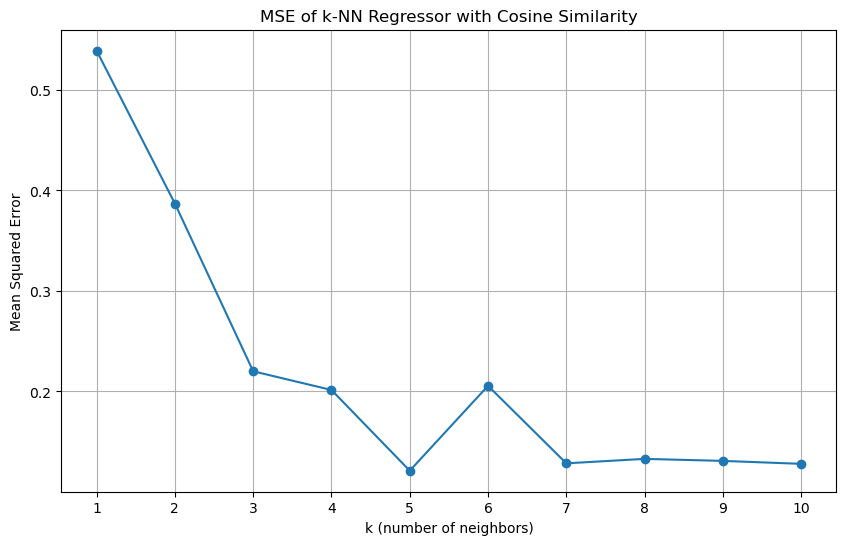

Best k (cosine): 5, MSE: 0.1212


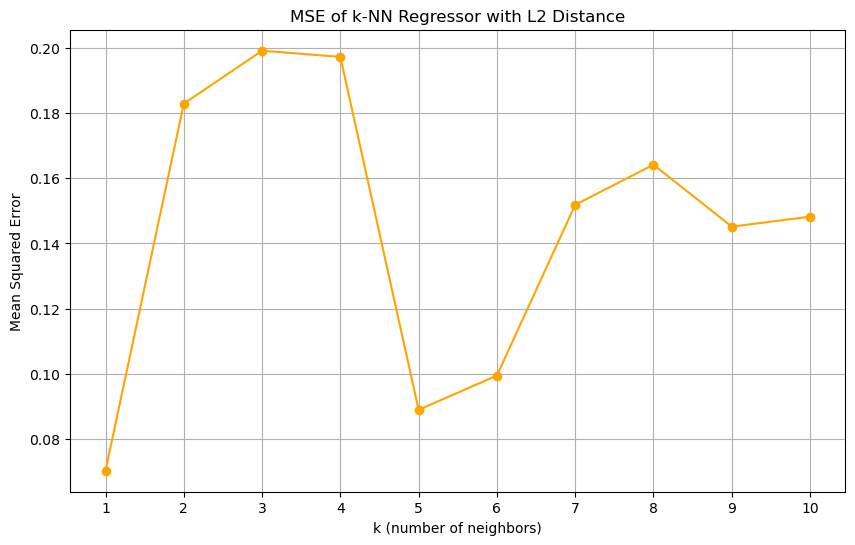

Best k (L2): 1, MSE: 0.0703
-----------
MSE: 0.1212
R²:  0.6131


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# load data
df = pd.read_csv('merged_features.csv')

# use most recent year per country so each country is only one row
latest = (
    df.sort_values('year', ascending=False)
    .groupby('geo', as_index=False)
    .first()
)

print(f"{len(latest)} countries loaded")
print(latest[['geo', 'combined_score']].sort_values('combined_score', ascending=False))


# build feature matrix and target vector
# Features: the four scaled columns already in the CSV
# Target: combined_score (higher = safer + more affordable)

feature_cols = ['noise_rate_scaled', 'pollution_rate_scaled',
                'crime_rate_scaled', 'hpi_weight_scaled']

X_mat = latest[feature_cols].to_numpy()
y_vec = latest['combined_score'].to_numpy()
country_labels = latest['geo'].to_numpy()


# train/test split

X_train_unscaled, X_test_unscaled, y_train, y_test = train_test_split(
    X_mat, y_vec, test_size=0.2, random_state=3000
)

# features are already scaled but we refit scaler on train only
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_unscaled)
X_test  = scaler.transform(X_test_unscaled)  # same scaler, no leakage


# KNN regressor

def my_knn_reg(X_train, y_train, X_test, k, similarity_metric='cosine'):
    """
    k-NN regressor for housing country scoring.

    Args:
        X_train: numpy array (n_samples, n_features) - training features
        y_train: numpy array (n_samples,) - training target values
        X_test:  numpy array (m_samples, n_features) - test features
        k: int - number of nearest neighbors
        similarity_metric: 'cosine' or 'l2'

    Returns:
        y_pred: numpy array (m_samples,) - predicted combined scores
        nearest_neighbors: list of lists - k neighbor indices per test point
    """
    y_pred = []
    nearest_neighbors = []

    for test_point in X_test:
        similarities = []

        for train_point in X_train:
            if similarity_metric == 'cosine':
                dot_product = np.dot(test_point, train_point)
                norm_test = np.linalg.norm(test_point)
                norm_train = np.linalg.norm(train_point)
                cosine_sim = dot_product / (norm_test * norm_train)
                similarities.append(cosine_sim)
            elif similarity_metric == 'l2':
                l2_distance = np.linalg.norm(test_point - train_point)
                similarities.append(-l2_distance)  # negative to sort descending

        neighbor_indices = np.argsort(similarities)[-k:]
        neighbor_values = y_train[neighbor_indices]

        y_pred.append(np.mean(neighbor_values))
        nearest_neighbors.append(neighbor_indices)

    return np.array(y_pred), nearest_neighbors


# finding k: cosine similarity

k_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
mse_values_cosine = []

for k in k_values:
    y_pred, _ = my_knn_reg(X_train, y_train, X_test, k, similarity_metric='cosine')
    mse = np.mean((y_test - y_pred) ** 2)
    mse_values_cosine.append(mse)

plt.figure(figsize=(10, 6))
plt.plot(k_values, mse_values_cosine, marker='o')
plt.title('MSE of k-NN Regressor with Cosine Similarity')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Mean Squared Error')
plt.xticks(k_values)
plt.grid()
plt.show()

best_k_cosine = k_values[np.argmin(mse_values_cosine)]
print(f"Best k (cosine): {best_k_cosine}, MSE: {min(mse_values_cosine):.4f}")


# finding k: L2 distance

mse_values_l2 = []

for k in k_values:
    y_pred_l2, _ = my_knn_reg(X_train, y_train, X_test, k, similarity_metric='l2')
    mse_l2 = np.mean((y_test - y_pred_l2) ** 2)
    mse_values_l2.append(mse_l2)

plt.figure(figsize=(10, 6))
plt.plot(k_values, mse_values_l2, marker='o', color='orange')
plt.title('MSE of k-NN Regressor with L2 Distance')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Mean Squared Error')
plt.xticks(k_values)
plt.grid()
plt.show()
best_k_l2 = k_values[np.argmin(mse_values_l2)]
print(f"Best k (L2): {best_k_l2}, MSE: {min(mse_values_l2):.4f}")


# success metrics
from sklearn.metrics import mean_squared_error, r2_score

y_pred_final, final_neighbors = my_knn_reg(
    X_train, y_train, X_test, k=5, similarity_metric='cosine'
)

print("-----------")
print(f"MSE: {mean_squared_error(y_test, y_pred_final):.4f}")
print(f"R²:  {r2_score(y_test, y_pred_final):.4f}")